<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">📈 Regresión avanzada: sobreajuste y regularización</h1>
<p style="margin:6px 0 0; opacity:0.8;">Aprendizaje supervisado — profundización en regresión más allá del dataset Iris</p>
</div>

En `../2-introduccion-machine-learning.ipynb` se presentó la regresión lineal simple y su aplicación al dataset **California Housing**, pero solo se ajustó un modelo lineal directo, sin explorar qué ocurre cuando el modelo es demasiado simple o demasiado complejo para los datos. Este notebook retoma el mismo dataset (California Housing) y utiliza además un ejemplo sintético 1D para hacer visible, de forma controlada, el fenómeno del sobreajuste, y para mostrar cómo la regularización (Ridge, Lasso, ElasticNet) permite controlarlo. Cierra con curvas de aprendizaje, una herramienta de diagnóstico que indica si conviene conseguir más datos, simplificar el modelo o añadir variables.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#sobreajuste">Sobreajuste con un ejemplo sintético 1D</a></li>
<li><a href="#regularizacion">Regularización sobre California Housing</a></li>
<li><a href="#curvas">Curvas de aprendizaje</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="sobreajuste"></a>

## <span style="color:#F97066;">Sobreajuste con un ejemplo sintético 1D</span>

Para observar el sobreajuste con total claridad, conviene partir de un problema donde se conoce la relación real entre las variables. Se genera un conjunto de datos con la forma $y = \sin(x) + \varepsilon$, donde $\varepsilon$ es ruido aleatorio, y se ajustan modelos de regresión polinomial de distintos grados usando `PolynomialFeatures` combinado con `LinearRegression`.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Un polinomio de grado bajo puede ser incapaz de capturar la curvatura real de los datos (subajuste o <em>underfitting</em>), mientras que uno de grado muy alto puede ajustarse casi perfectamente al ruido de los datos de entrenamiento, perdiendo capacidad de generalizar (sobreajuste u <em>overfitting</em>).
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

# 1. Generar datos sintéticos: y = sin(x) + ruido
rng = np.random.RandomState(42)
X = np.sort(rng.uniform(0, 2 * np.pi, 120)).reshape(-1, 1)
y = np.sin(X).ravel() + rng.normal(scale=0.25, size=X.shape[0])

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (84, 1)
Dimensiones de X_test: (36, 1)


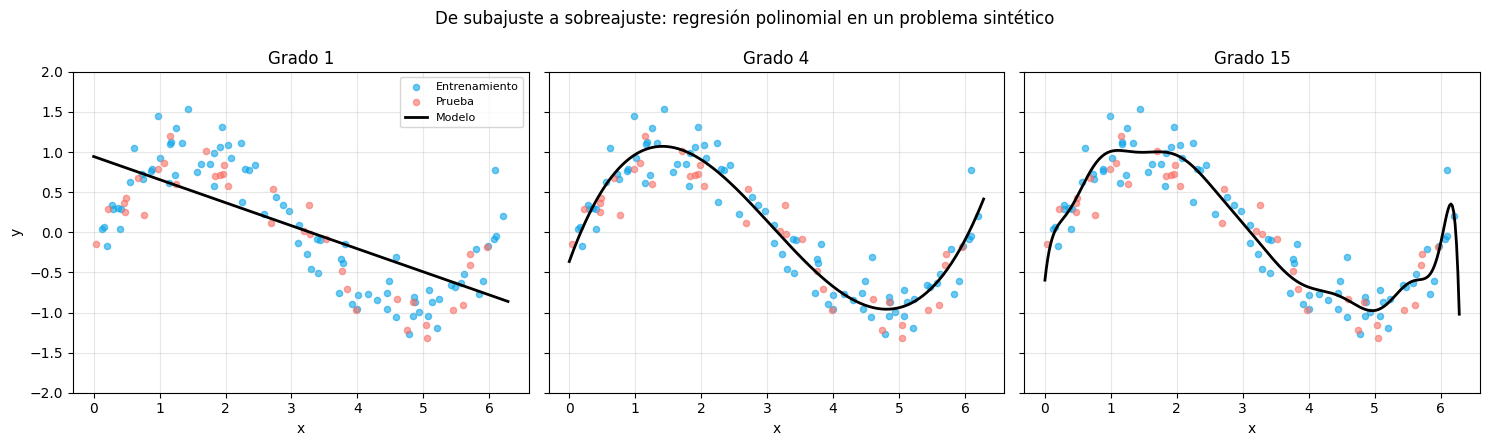

In [2]:
# 3. Ajustar modelos polinomiales de distinto grado
grados = [1, 4, 15]
X_linea = np.linspace(0, 2 * np.pi, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, grado in zip(axes, grados):
    modelo = make_pipeline(PolynomialFeatures(degree=grado), LinearRegression())
    modelo.fit(X_train, y_train)

    ax.scatter(X_train, y_train, color='#0EA5E9', s=20, alpha=0.6, label='Entrenamiento')
    ax.scatter(X_test, y_test, color='#F97066', s=20, alpha=0.6, label='Prueba')
    ax.plot(X_linea, modelo.predict(X_linea), color='black', linewidth=2, label='Modelo')
    ax.set_title(f"Grado {grado}")
    ax.set_xlabel("x")
    ax.set_ylim(-2, 2)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("y")
axes[0].legend(loc='upper right', fontsize=8)
fig.suptitle("De subajuste a sobreajuste: regresión polinomial en un problema sintético")
plt.tight_layout()
plt.show()

Se observa que el modelo de grado 1 (una recta) no logra capturar la forma senoidal de los datos: subajuste. El de grado 15, en cambio, oscila para pasar lo más cerca posible de cada punto de entrenamiento, incluyendo su ruido: sobreajuste. El de grado 4 logra un balance razonable.

Para cuantificar este efecto de forma más precisa, se calcula el error cuadrático medio (MSE) de entrenamiento y de prueba variando el grado del polinomio de 1 a 20.

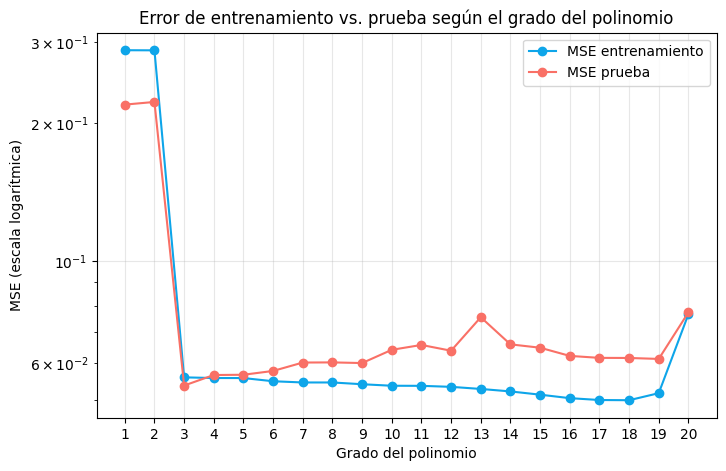

Grado con menor MSE de prueba: 3


In [3]:
# 4. Curva de error (MSE) de entrenamiento vs. prueba en función del grado
grados_rango = range(1, 21)
mse_train, mse_test = [], []

for grado in grados_rango:
    modelo = make_pipeline(PolynomialFeatures(degree=grado), LinearRegression())
    modelo.fit(X_train, y_train)
    mse_train.append(mean_squared_error(y_train, modelo.predict(X_train)))
    mse_test.append(mean_squared_error(y_test, modelo.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(grados_rango), mse_train, marker='o', color='#0EA5E9', label='MSE entrenamiento')
plt.plot(list(grados_rango), mse_test, marker='o', color='#F97066', label='MSE prueba')
plt.yscale('log')
plt.xlabel("Grado del polinomio")
plt.ylabel("MSE (escala logarítmica)")
plt.title("Error de entrenamiento vs. prueba según el grado del polinomio")
plt.xticks(list(grados_rango))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

grado_optimo = list(grados_rango)[int(np.argmin(mse_test))]
print(f"Grado con menor MSE de prueba: {grado_optimo}")

El MSE de entrenamiento disminuye de forma monótona a medida que crece el grado del polinomio: un modelo más flexible siempre puede ajustar mejor los datos que ya vio. El MSE de prueba, en cambio, describe una curva en forma de "U": primero baja porque el modelo deja de subajustar, alcanza un mínimo, y luego vuelve a subir porque el modelo empieza a memorizar el ruido en lugar de la señal. Ese punto mínimo señala el grado que generaliza mejor — la meta de la regularización, en la siguiente sección, es lograr un efecto equivalente sin tener que elegir manualmente la complejidad del modelo.

<a id="regularizacion"></a>

## <span style="color:#F97066;">Regularización sobre California Housing</span>

El dataset **California Housing** (el mismo del notebook principal) se usa aquí para comparar la Regresión Lineal simple contra tres variantes regularizadas: **Ridge** (penalización $L_2$), **Lasso** (penalización $L_1$) y **ElasticNet** (combinación de ambas). Para que la regularización tenga un efecto visible se generan más variables mediante `PolynomialFeatures` de grado 2 (interacciones y términos cuadráticos de las 8 variables originales), lo que produce un modelo con muchos más coeficientes y, por lo tanto, más propenso al sobreajuste sin control.

In [4]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Cargar datos
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Expandir a características polinomiales de grado 2 y escalar
poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(poly.fit_transform(X_train))
X_test_poly = scaler.transform(poly.transform(X_test))

print(f"Variables originales: {X_train.shape[1]}")
print(f"Variables tras PolynomialFeatures (grado 2): {X_train_poly.shape[1]}")

Variables originales: 8
Variables tras PolynomialFeatures (grado 2): 44


In [5]:
# 4. Modelo base: Regresión Lineal (sin regularizar) sobre las mismas variables expandidas
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_poly, y_train)
pred_lineal = modelo_lineal.predict(X_test_poly)

print("Regresión Lineal (baseline, sin regularización):")
print(f"  MSE prueba: {mean_squared_error(y_test, pred_lineal):.4f}")
print(f"  R² prueba: {r2_score(y_test, pred_lineal):.4f}")
print(f"  Suma de |coeficientes|: {np.abs(modelo_lineal.coef_).sum():.2f}")

Regresión Lineal (baseline, sin regularización):
  MSE prueba: 0.4643
  R² prueba: 0.6457
  Suma de |coeficientes|: 357.91


In [6]:
# 5. Ridge, Lasso y ElasticNet con selección automática de alpha por validación cruzada
alphas = np.logspace(-3, 2, 30)

modelo_ridge = RidgeCV(alphas=alphas, cv=5)
modelo_ridge.fit(X_train_poly, y_train)

modelo_lasso = LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=42)
modelo_lasso.fit(X_train_poly, y_train)

modelo_elastic = ElasticNetCV(alphas=alphas, l1_ratio=[.1, .3, .5, .7, .9, .95, 1], cv=5, max_iter=20000, random_state=42)
modelo_elastic.fit(X_train_poly, y_train)

resultados = {}
for nombre, modelo in [("Ridge", modelo_ridge), ("Lasso", modelo_lasso), ("ElasticNet", modelo_elastic)]:
    pred = modelo.predict(X_test_poly)
    resultados[nombre] = {
        "alpha": modelo.alpha_,
        "mse": mean_squared_error(y_test, pred),
        "r2": r2_score(y_test, pred),
        "coefs_cero": int(np.sum(np.isclose(modelo.coef_, 0))),
        "suma_abs_coefs": np.abs(modelo.coef_).sum(),
    }

for nombre, r in resultados.items():
    print(f"{nombre}: alpha={r['alpha']:.4f} | MSE={r['mse']:.4f} | R²={r['r2']:.4f} | "
          f"coeficientes en cero={r['coefs_cero']}/{len(modelo_ridge.coef_)} | suma |coef|={r['suma_abs_coefs']:.2f}")

/private/tmp/sup_avanzado_venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.441324429438282, tolerance: 1.754970336511493
  model = cd_fast.enet_coordinate_descent_gram(


Ridge: alpha=0.1743 | MSE=0.4545 | R²=0.6532 | coeficientes en cero=0/44 | suma |coef|=102.00
Lasso: alpha=0.0073 | MSE=0.5587 | R²=0.5737 | coeficientes en cero=28/44 | suma |coef|=3.32
ElasticNet: alpha=0.0073 | MSE=0.5588 | R²=0.5736 | coeficientes en cero=26/44 | suma |coef|=3.37


<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.9em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Modelo</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Penalización</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Efecto sobre los coeficientes</th>
</tr>
</thead>
<tbody>
<tr style="background:rgba(14,165,233,0.07);"><td style="padding:6px 14px;">Ridge</td><td style="padding:6px 14px;">$L_2$ (suma de cuadrados)</td><td style="padding:6px 14px;">Reduce la magnitud de todos los coeficientes de forma suave, pero rara vez los lleva exactamente a cero.</td></tr>
<tr><td style="padding:6px 14px;">Lasso</td><td style="padding:6px 14px;">$L_1$ (suma de valores absolutos)</td><td style="padding:6px 14px;">Puede llevar coeficientes exactamente a cero, actuando como un mecanismo de selección de variables.</td></tr>
<tr style="background:rgba(14,165,233,0.07);"><td style="padding:6px 14px;">ElasticNet</td><td style="padding:6px 14px;">Combinación de $L_1$ y $L_2$</td><td style="padding:6px 14px;">Combina ambos efectos; útil cuando hay grupos de variables correlacionadas entre sí.</td></tr>
</tbody>
</table>
</div>

La celda anterior confirma esta diferencia de forma numérica: Lasso y ElasticNet llevan una parte de los coeficientes exactamente a cero (funcionando como selectores automáticos de variables entre todas las combinaciones polinomiales generadas), mientras que Ridge conserva todos los coeficientes distintos de cero, solo reduce su magnitud. Esto ocurre porque la penalización $L_1$ tiene "esquinas" en el origen de su superficie de restricción, lo que hace que la solución óptima caiga frecuentemente exactamente sobre un eje (coeficiente cero); la penalización $L_2$, al ser una esfera suave, no tiene esa propiedad.

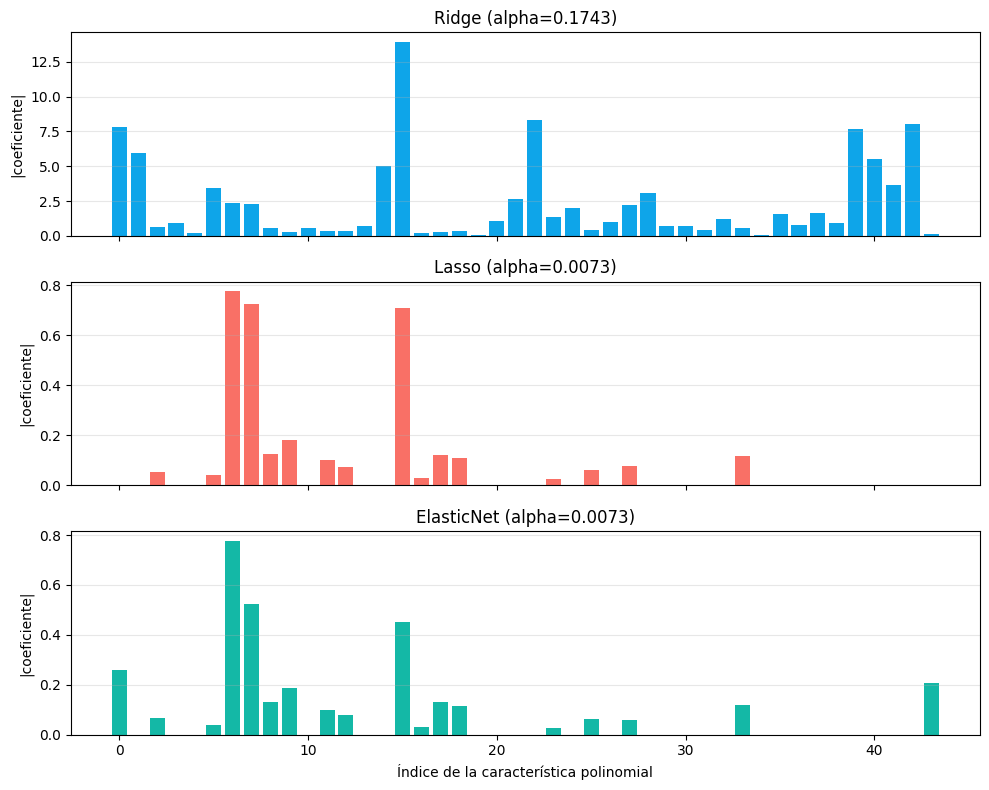

In [7]:
# 6. Comparación visual de los coeficientes (valor absoluto) de cada modelo
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
modelos_coef = [("Ridge", modelo_ridge, '#0EA5E9'), ("Lasso", modelo_lasso, '#F97066'), ("ElasticNet", modelo_elastic, '#14B8A6')]

for ax, (nombre, modelo, color) in zip(axes, modelos_coef):
    ax.bar(range(len(modelo.coef_)), np.abs(modelo.coef_), color=color)
    ax.set_title(f"{nombre} (alpha={modelo.alpha_:.4f})")
    ax.set_ylabel("|coeficiente|")
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel("Índice de la característica polinomial")
plt.tight_layout()
plt.show()

<a id="curvas"></a>

## <span style="color:#F97066;">Curvas de aprendizaje</span>

Una curva de aprendizaje muestra cómo cambia el desempeño del modelo (en entrenamiento y en validación cruzada) a medida que aumenta la cantidad de datos de entrenamiento usados. Es una herramienta de diagnóstico: permite distinguir si un modelo sufre de **alto sesgo** (ambas curvas convergen a un desempeño bajo — más datos no ayudarían) o de **alta varianza** (hay una brecha amplia entre entrenamiento y validación — más datos sí podrían ayudar). Se aplica sobre Ridge, el modelo regularizado que mejor equilibrio mostró entre sesgo y varianza en la sección anterior.

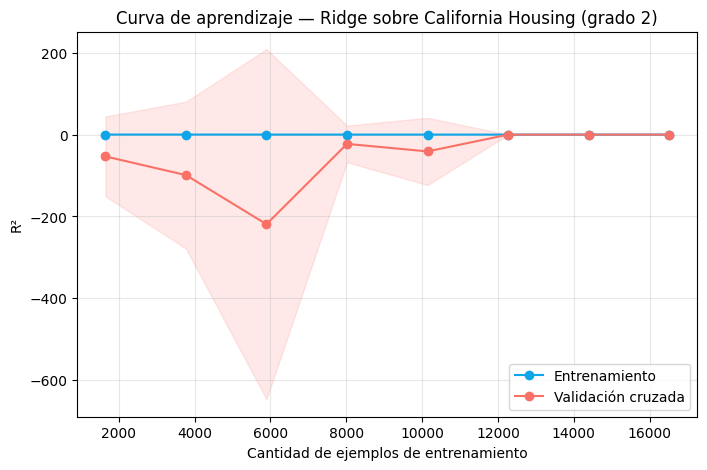

R² final entrenamiento: 0.6622
R² final validación cruzada: 0.5442


In [8]:
from sklearn.model_selection import learning_curve

X_completo = np.vstack([X_train_poly, X_test_poly])
y_completo = np.concatenate([y_train, y_test])

tamanos_entrenamiento, scores_train, scores_val = learning_curve(
    RidgeCV(alphas=alphas, cv=5),
    X_completo, y_completo,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='r2',
    n_jobs=-1,
)

train_mean, train_std = scores_train.mean(axis=1), scores_train.std(axis=1)
val_mean, val_std = scores_val.mean(axis=1), scores_val.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(tamanos_entrenamiento, train_mean, 'o-', color='#0EA5E9', label='Entrenamiento')
plt.fill_between(tamanos_entrenamiento, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#0EA5E9')
plt.plot(tamanos_entrenamiento, val_mean, 'o-', color='#F97066', label='Validación cruzada')
plt.fill_between(tamanos_entrenamiento, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#F97066')
plt.xlabel("Cantidad de ejemplos de entrenamiento")
plt.ylabel("R²")
plt.title("Curva de aprendizaje — Ridge sobre California Housing (grado 2)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"R² final entrenamiento: {train_mean[-1]:.4f}")
print(f"R² final validación cruzada: {val_mean[-1]:.4f}")

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Si la brecha entre las dos curvas se mantiene amplia incluso con muchos datos, el problema es de varianza y ayudaría regularizar más, simplificar el modelo o conseguir más datos. Si ambas curvas convergen a un valor de R² relativamente bajo, el problema es de sesgo, y ayudaría un modelo más flexible o más variables — no más datos. En este caso, la brecha moderada y el R² final indican que el modelo se beneficia de la regularización, pero también que el conjunto de variables (incluso expandido con `PolynomialFeatures`) impone un techo al desempeño alcanzable con un modelo lineal.
</div>

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>

- Se observó el sobreajuste de forma controlada con un ejemplo sintético 1D, ajustando polinomios de distinto grado y comparando el MSE de entrenamiento vs. prueba.
- Se comparó la Regresión Lineal simple contra Ridge, Lasso y ElasticNet sobre California Housing con variables polinomiales de grado 2, seleccionando `alpha` por validación cruzada.
- Se explicó por qué Lasso lleva coeficientes exactamente a cero (selección de variables) y Ridge no.
- Se usaron curvas de aprendizaje para diagnosticar si el modelo final sufre de sesgo alto o varianza alta.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>2-clasificacion-avanzada.ipynb</code> — el mismo tipo de profundización, ahora aplicado a modelos de clasificación (Regresión Logística, SVM y Árboles de Decisión) sobre el dataset Wine.</li>
</ul>
</div>